### Agentic RAG
🤖 What is Agentic RAG?

Agentic RAG stands for Agentic Retrieval-Augmented Generation — an advanced version of RAG where instead of a static, one-shot LLM response,the system uses an agent that:

- reasons,
- plans,
- retrieves,
- uses tools,
- and even retries or reflects
to generate better, more grounded answers.

### 🤖 What is ReAct?
ReAct (Reasoning + Acting) is a framework where an LLM:

- Reasons step-by-step (e.g. decomposes questions, makes decisions)

- Acts by calling tools like search, calculators, or retrievers

This makes it perfect for Agentic RAG:
✅ Think → Retrieve → Observe → Reflect → Final Answer

In [ ]:
# --- Imports ---
import os
from typing import List
from dotenv import load_dotenv

from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langgraph.graph import StateGraph, END
from pydantic import BaseModel
from langchain_core.messages import SystemMessage, HumanMessage


# --- Configuration ---
load_dotenv()

# init_chat_model will read OPENAI_API_KEY from the environment automatically;
# no need to re-assign it via os.environ.
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
llm = init_chat_model("openai:gpt-4o")

c:\Users\Parth\Downloads\Agentic_Rag\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
# -----------------------------------------------
# 1. Document Preprocessing
# -----------------------------------------------
# Load web pages, split them into chunks, and index
# them into a FAISS vector store for similarity search.

URLS = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/",
]

# Load raw HTML content from each URL
docs = []
for url in URLS:
    docs.extend(WebBaseLoader(url).load())

# Split documents into overlapping chunks to preserve context across boundaries
# Use semantic-aware separators so splits happen at natural boundaries
# (sections → paragraphs → sentences → words) before falling back to characters.
# chunk_size=800 gives enough context per chunk for technical blog posts.
# chunk_overlap=100 prevents key sentences from being lost at chunk edges.
splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n\n", "\n\n", "\n", ". ", " ", ""],
    chunk_size=800,
    chunk_overlap=100,
    length_function=len,
    add_start_index=True,   # stores char offset in metadata — useful for debugging
)
split_docs = splitter.split_documents(docs)



In [3]:
### Vector Store Setup with FAISS and MMR Retriever

FAISS_INDEX_PATH = "faiss_index"

embedding = OpenAIEmbeddings(
    model="text-embedding-3-small",  # cheaper + faster than ada-002, often better
    chunk_size=200,                  # batch size for embedding API calls — avoids rate limits
)

# Load from disk if it already exists, otherwise build and save.
# This avoids re-embedding on every run — critical for cost and speed.
if os.path.exists(FAISS_INDEX_PATH):
    vectorstore = FAISS.load_local(
        FAISS_INDEX_PATH,
        embeddings=embedding,
        allow_dangerous_deserialization=True,  # required by LangChain for local loads
    )
    print("Loaded FAISS index from disk.")
else:
    vectorstore = FAISS.from_documents(split_docs, embedding)
    vectorstore.save_local(FAISS_INDEX_PATH)
    print(f"Built and saved FAISS index ({len(split_docs)} chunks).")

# Use MMR (Maximal Marginal Relevance) instead of plain similarity search.
# MMR balances relevance with diversity — prevents 5 near-duplicate chunks
# from all being returned for the same query.
retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k": 5,           # number of chunks to return
        "fetch_k": 20,    # candidate pool MMR selects from — larger = more diverse results
        "lambda_mult": 0.6,  # 0=max diversity, 1=max relevance; 0.6 is a good default
    },
)

Built and saved FAISS index (155 chunks).


In [4]:
# -----------------------------------------------
# 2. RAG State Schema
# -----------------------------------------------

class RAGState(BaseModel):
    """
    Typed state object passed between LangGraph nodes.

    Attributes:
        question: The user's input question.
        retrieved_docs: Documents fetched from the vector store.
        answer: The LLM-generated response.
    """
    question: str
    retrieved_docs: List[Document] = []
    answer: str = ""

In [5]:
# -----------------------------------------------
# 3. LangGraph Node Functions
# -----------------------------------------------
from langchain_core.documents import Document

def retrieve_docs(state: RAGState) -> RAGState:
    """Retrieve relevant docs, filtering out any below a similarity threshold."""
    # score_threshold filters chunks that are too semantically distant from the query
    docs_with_scores = vectorstore.similarity_search_with_relevance_scores(
        state.question, k=5
    )
    filtered_docs = [
        doc for doc, score in docs_with_scores if score >= 0.3
    ]
    return RAGState(question=state.question, retrieved_docs=filtered_docs)


def generate_answer(state: RAGState) -> RAGState:
    """
    Generate a grounded answer using retrieved context.
    
    Uses a structured system prompt to enforce citation behavior,
    prevent hallucination, and handle cases where context is insufficient.
    """
    # Format each chunk with its source URL for traceable citations
    context_blocks = []
    for i, doc in enumerate(state.retrieved_docs):
        source = doc.metadata.get("source", "Unknown")
        context_blocks.append(f"[{i+1}] (Source: {source})\n{doc.page_content}")
    
    context = "\n\n---\n\n".join(context_blocks)

    system_prompt = """You are a precise and trustworthy research assistant.

Your job is to answer questions using ONLY the context provided below. Follow these rules strictly:

1. **Grounded answers only** — Do not use any knowledge outside the provided context.
2. **Cite your sources** — Reference chunks by their [number] when using information from them.
3. **Admit uncertainty** — If the context does not contain enough information to answer the question, say:
   "The provided context does not contain sufficient information to answer this question."
   Do NOT guess or infer beyond what is explicitly stated.
4. **Be concise** — Answer in clear, structured prose. Use bullet points only when listing distinct items.
5. **No repetition** — Do not restate the question or summarize the context back to the user."""

    human_prompt = f"""Context:
{context}

Question: {state.question}

Answer (cite sources by [number]):"""

    response = llm.invoke([
        SystemMessage(content=system_prompt),
        HumanMessage(content=human_prompt),
    ])

    return RAGState(
        question=state.question,
        retrieved_docs=state.retrieved_docs,
        answer=response.content,
    )

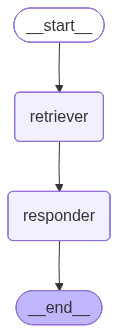

In [6]:
# -----------------------------------------------
# 4. Build the LangGraph Workflow
# -----------------------------------------------

builder = StateGraph(RAGState)

# Register nodes
builder.add_node("retriever", retrieve_docs)
builder.add_node("responder", generate_answer)

# Define the linear execution flow: retriever → responder → END
builder.set_entry_point("retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", END)

graph = builder.compile()
graph

In [7]:
# -----------------------------------------------
# 5. Run the Agentic RAG Pipeline
# -----------------------------------------------

if __name__ == "__main__":
    USER_QUESTION = "What is the concept of agent loop in autonomous agents?"
    
    initial_state = RAGState(question=USER_QUESTION)
    final_state = graph.invoke(initial_state)

    print("\n✅ Final Answer:\n", final_state["answer"])


✅ Final Answer:
 The provided context does not contain sufficient information to answer this question.


In [8]:
final_state

{'question': 'What is the concept of agent loop in autonomous agents?',
 'retrieved_docs': [Document(id='52a1f184-8692-4c14-9f4f-39e791feaf8b', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism an